In [1]:
import numpy as np
import meanderpy as mp
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import viridis
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
mpl.rcParams['figure.dpi'] = 1000  

In [2]:
from scipy import interpolate
import numpy as np
import meanderpy as mp  # assuming you already have this

def run_meander_simulation(freq_multiplier=1, amplitude=1, multiplier=1,
                           perturb=False, perturb_value=1e-15, perturb_index=None):
    nit = 1001
    W = 50.0                 
    D = 1.0                  
    depths = D * np.ones((nit,))
    pad = 0
    deltas = 50.0
    Cfs = 0.0065 * np.ones((nit,))
    crdist = 3 * W
    kl = 500.0 / (365 * 24 * 60 * 60.0) 
    kv = 1.0e-12
    dt = 0.1 * 0.5 * 365 * 24 * 60 * 60.0
    dens = 1000
    saved_ts = 1                
    Sl = 0.0
    t1, t2, t3 = 0, 0, 0
    aggr_factor = 2e-19

    # Generate initial geometry
    x_initial = np.linspace(0.1, 10000, 1500)
    y_initial = (amplitude * 100) * np.sin(freq_multiplier * np.pi * x_initial / 1000.0)
    z_initial = np.zeros_like(x_initial)

    # Apply perturbation
    if perturb:
        if perturb_index is None:
            perturb_index = len(y_initial) // 2  # default to midpoint
        y_initial[perturb_index] += perturb_value

    ch = mp.Channel(x_initial, y_initial, z_initial, W, depths[0])
    chb = mp.ChannelBelt([ch], [], [0.0], [])
    chb.migrate(nit, saved_ts, deltas, pad, crdist, depths, Cfs, kl, kv, dt, dens, t1, t2, t3, aggr_factor)
    return chb

In [3]:
# No perturbation
chb1 = run_meander_simulation(perturb=False)

# Perturb node 700 by 1e-15
chb2 = run_meander_simulation(perturb=True, perturb_value=1e-15, perturb_index=300)

100%|██████████| 1001/1001 [00:07<00:00, 134.49it/s]


Figure 1a schematics

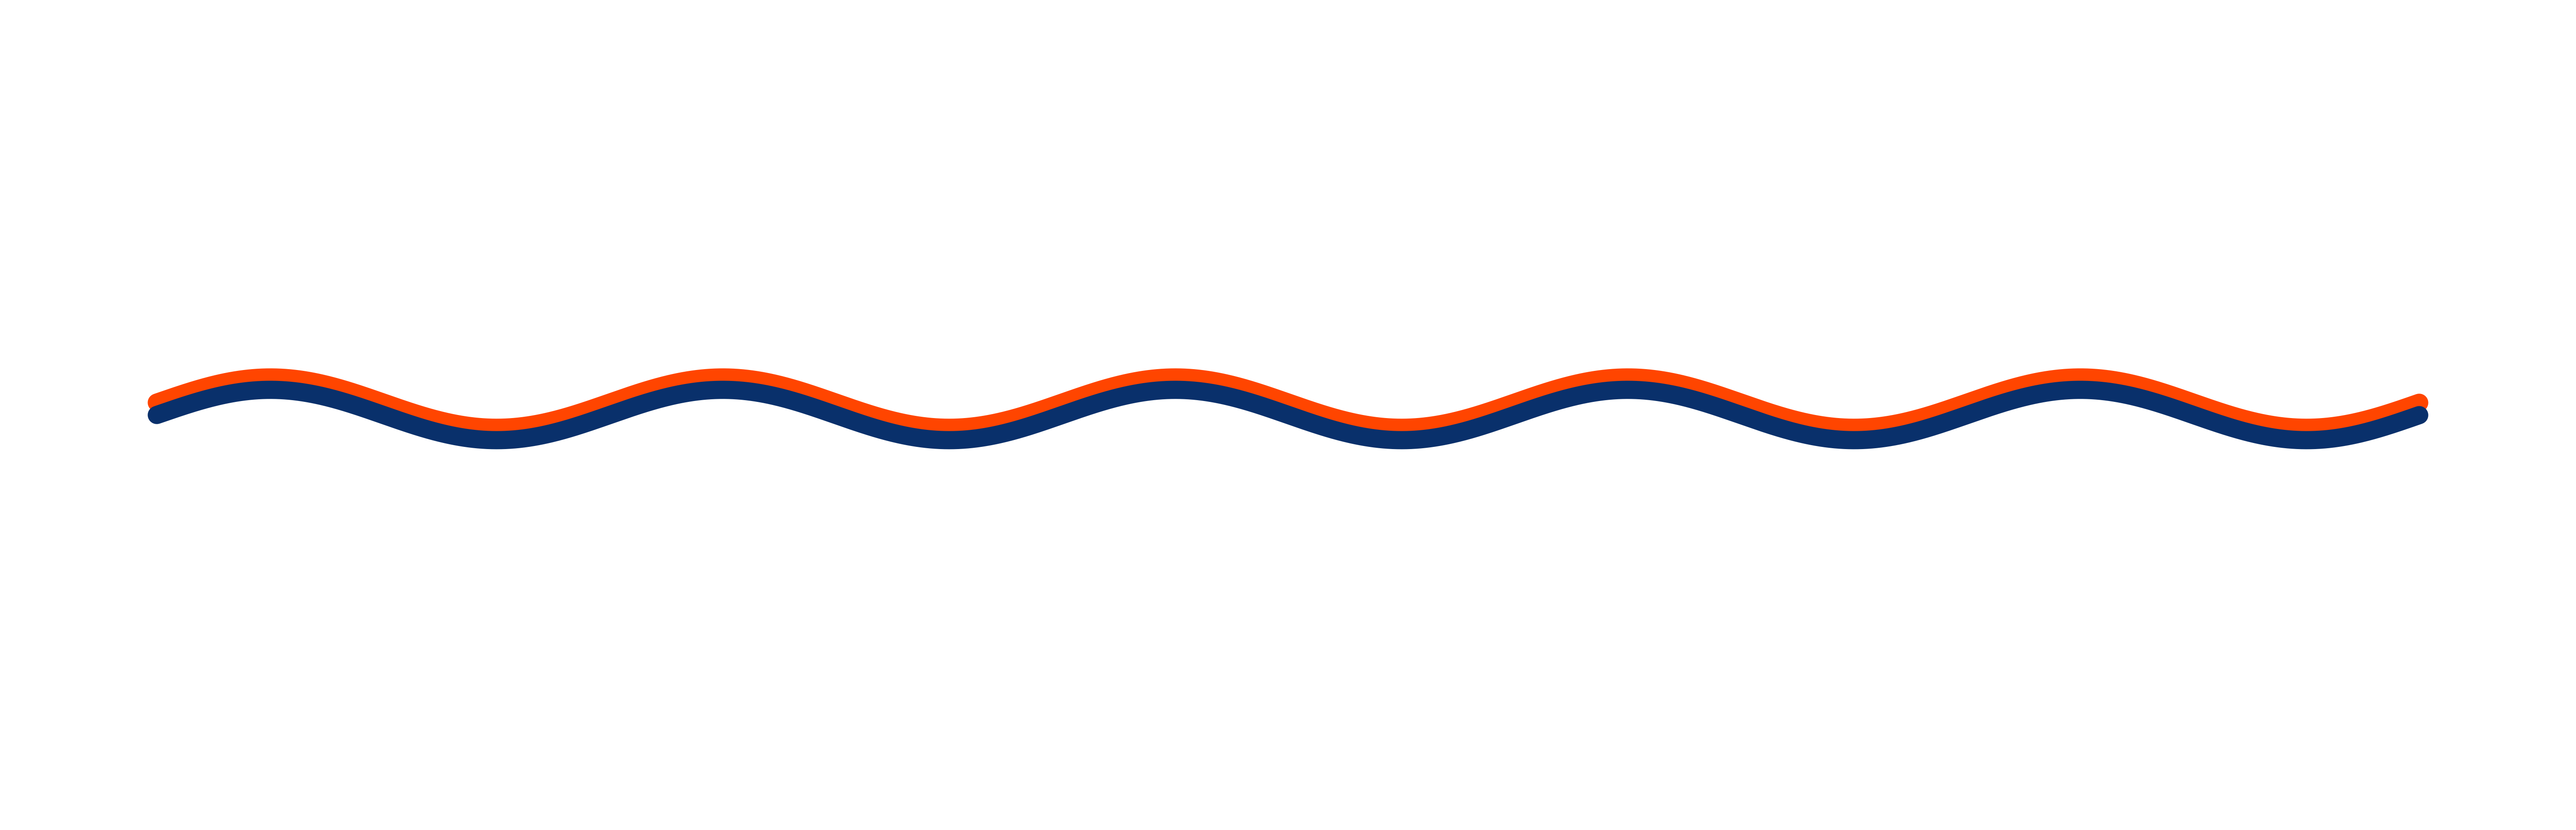

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 2))
time = 0

# Shift the orange channel (chb1) by +5 units in the y-direction
shifted_y = chb1.channels[time].y[::1] + 50

plt.plot(chb1.channels[time].x[::1], shifted_y, lw=3, c='orangered', solid_capstyle='round')
plt.plot(chb2.channels[time].x[::1], chb2.channels[time].y[::1], lw=3, color='#09306b', solid_capstyle='round')

plt.xlabel('X')
plt.ylabel('Y')
plt.ylim([-1500, 1500])
plt.axis("off")
plt.tight_layout()
plt.show()

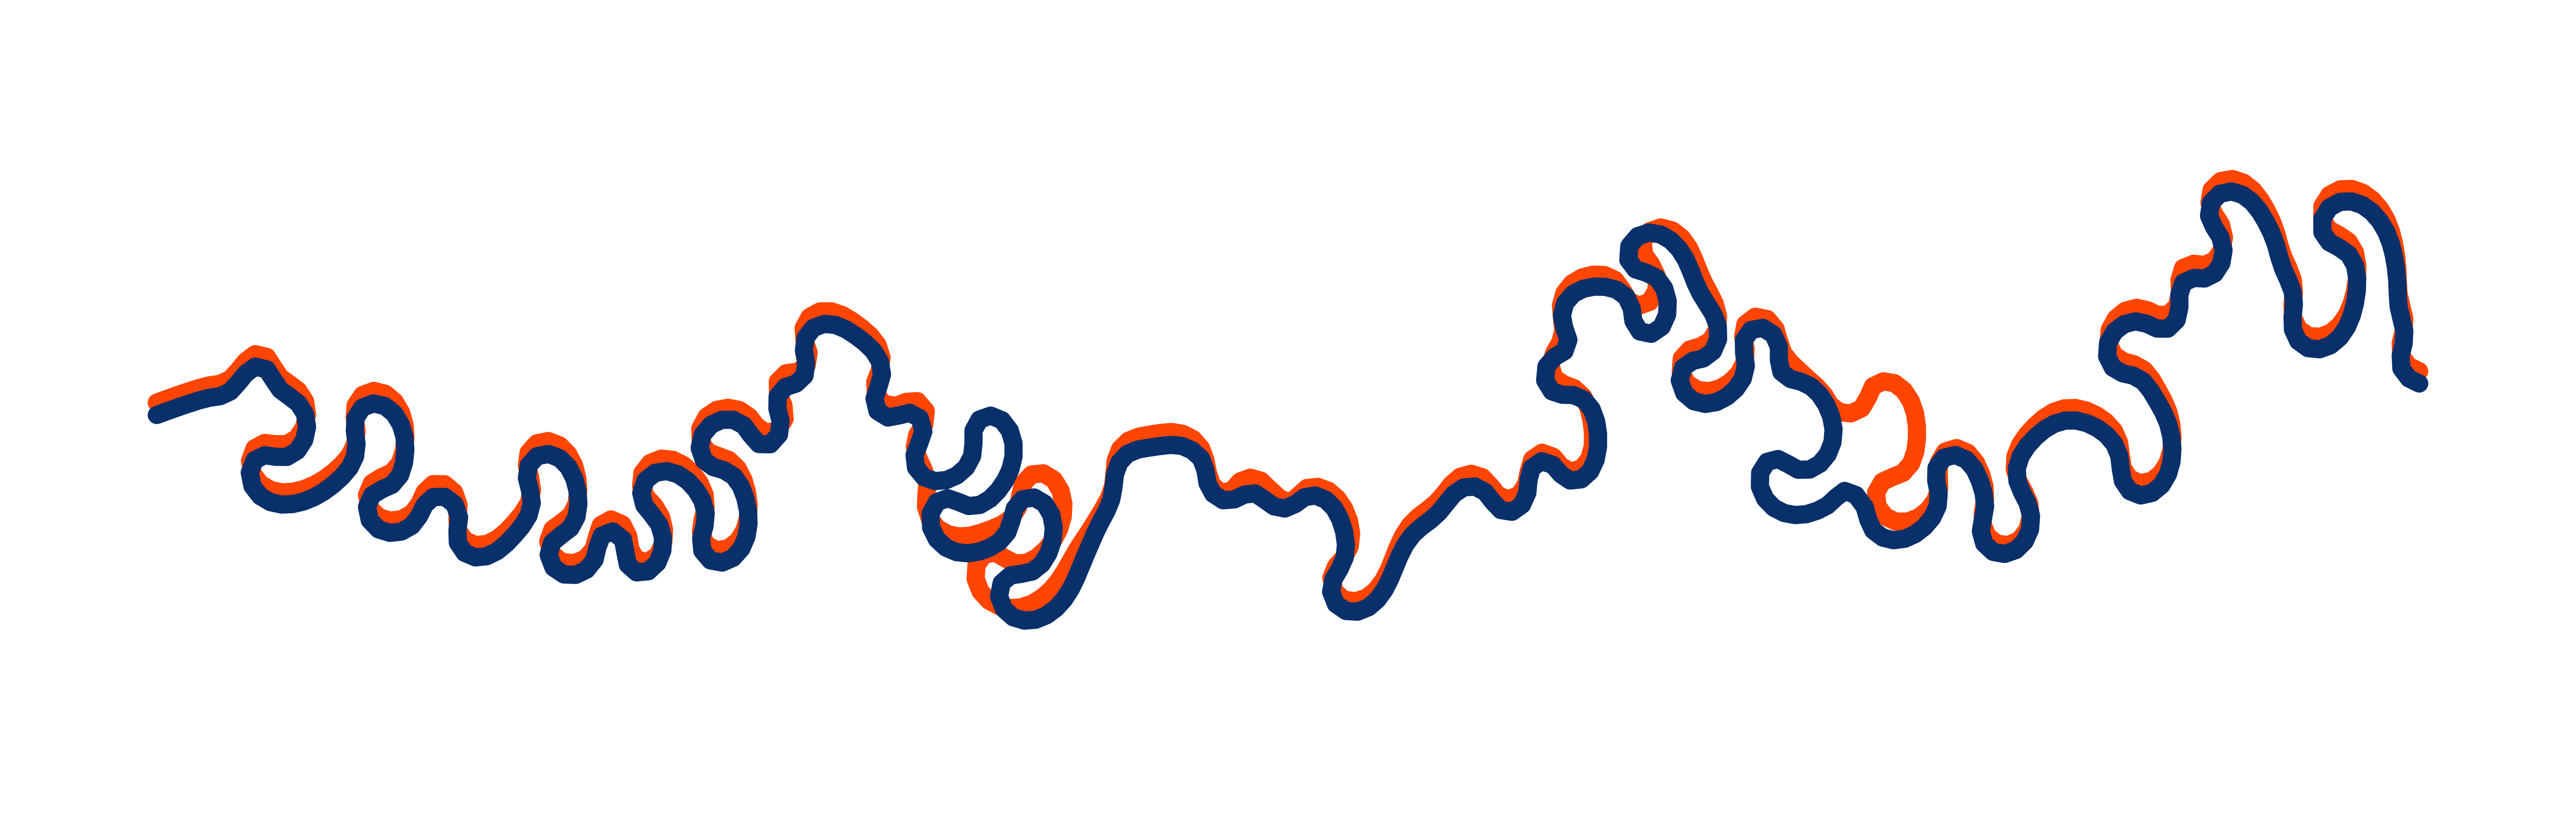

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 2))
time = 400

# Shift the orange channel (chb1) by +5 units in the y-direction
shifted_y = chb1.channels[time].y[::1] + 50

plt.plot(chb1.channels[time].x[::1], shifted_y, lw=3, c='orangered', solid_capstyle='round')
plt.plot(chb2.channels[time].x[::1], chb2.channels[time].y[::1], lw=3, color='#09306b', solid_capstyle='round')

plt.xlabel('X')
plt.ylabel('Y')
plt.ylim([-1500, 1500])
plt.axis("off")
plt.tight_layout()
plt.show()

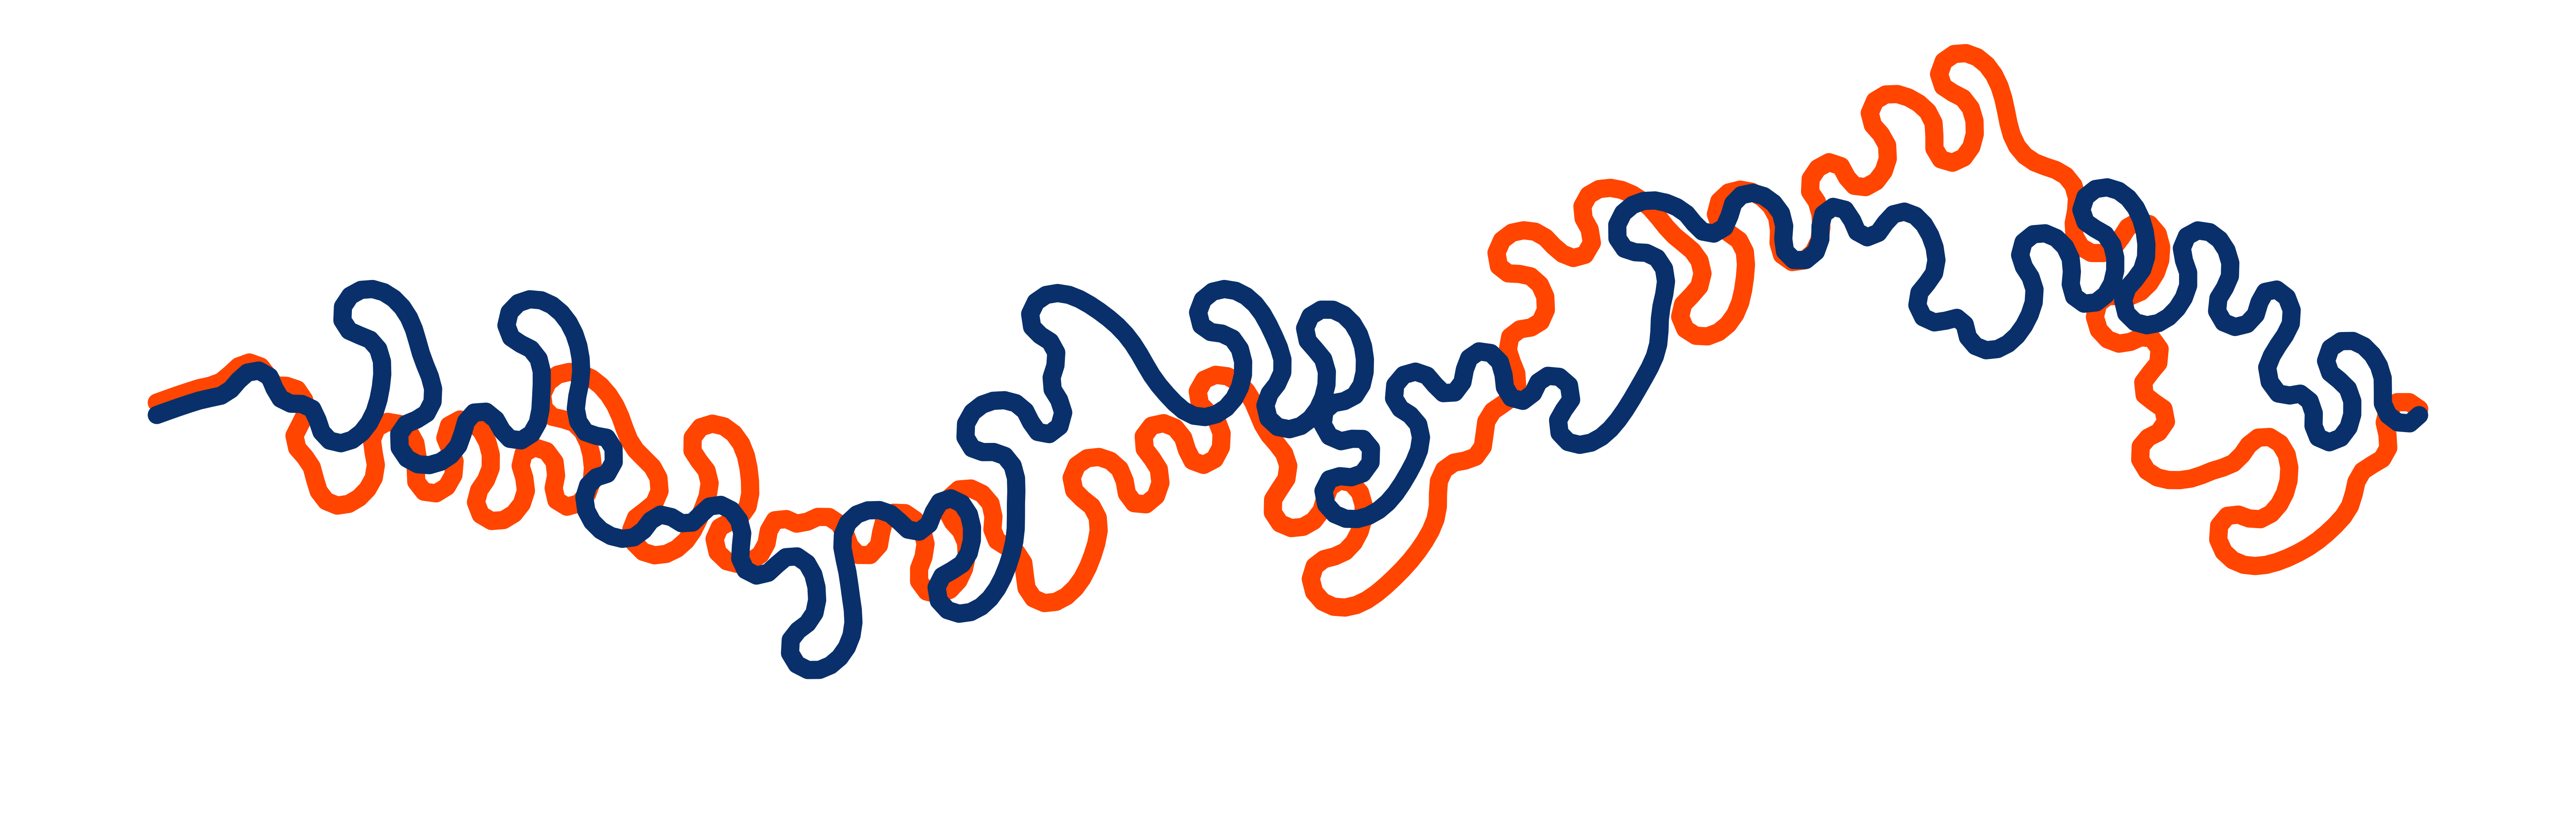

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 2))
time = 600

# Shift the orange channel (chb1) by +5 units in the y-direction
shifted_y = chb1.channels[time].y[::1] + 50

plt.plot(chb1.channels[time].x[::1], shifted_y, lw=3, c='orangered', solid_capstyle='round')
plt.plot(chb2.channels[time].x[::1], chb2.channels[time].y[::1], lw=3, color='#09306b', solid_capstyle='round')

plt.xlabel('X')
plt.ylabel('Y')
plt.ylim([-1500, 1500])
plt.axis("off")
plt.tight_layout()
plt.show()

Figure 1b

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

def run_meander_simulation(freq_multiplier=1, amplitude=1, multiplier=1,
                           perturb=False, perturb_value=1e-15, perturb_index=None):
    nit = 501
    W = 50.0                 
    D = 1.0                  
    depths = D * np.ones((nit,))
    pad = 0
    deltas = 50.0
    Cfs = 0.0065 * np.ones((nit,))
    crdist = 3 * W
    kl = 500.0 / (365 * 24 * 60 * 60.0) 
    kv = 1.0e-12
    dt = 0.1 * 0.5 * 365 * 24 * 60 * 60.0
    dens = 1000
    saved_ts = 1                
    Sl = 0.0
    t1, t2, t3 = 0, 0, 0
    aggr_factor = 2e-19

    # Generate initial geometry
    x_initial = np.linspace(0.1, 10000, 1500)
    y_initial = (amplitude * 100) * np.sin(freq_multiplier * np.pi * x_initial / 1000.0)
    z_initial = np.zeros_like(x_initial)

    # Apply perturbation
    if perturb:
        if perturb_index is None:
            perturb_index = len(y_initial) // 2  # default to midpoint
        y_initial[perturb_index] += perturb_value

    ch = mp.Channel(x_initial, y_initial, z_initial, W, depths[0])
    chb = mp.ChannelBelt([ch], [], [0.0], [])
    chb.migrate(nit, saved_ts, deltas, pad, crdist, depths, Cfs, kl, kv, dt, dens, t1, t2, t3, aggr_factor)
    return chb


# Generate unperturbed channel
chb1 = run_meander_simulation(perturb=False)

# Generate perturbed variations (node positions 0 to 300)
perturb_indices = np.linspace(0, 300, 5 , dtype=int)
perturbed_channels = [
    run_meander_simulation(perturb=True, perturb_value=1e-10, perturb_index=idx)
    for idx in perturb_indices
]

100%|██████████| 501/501 [00:02<00:00, 179.12it/s]


/var/folders/pv/vxz_z6x905j13byjd_vxl_br0000gn/T/ipykernel_14381/2607148266.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Blues', len(perturbed_channels) + 1)


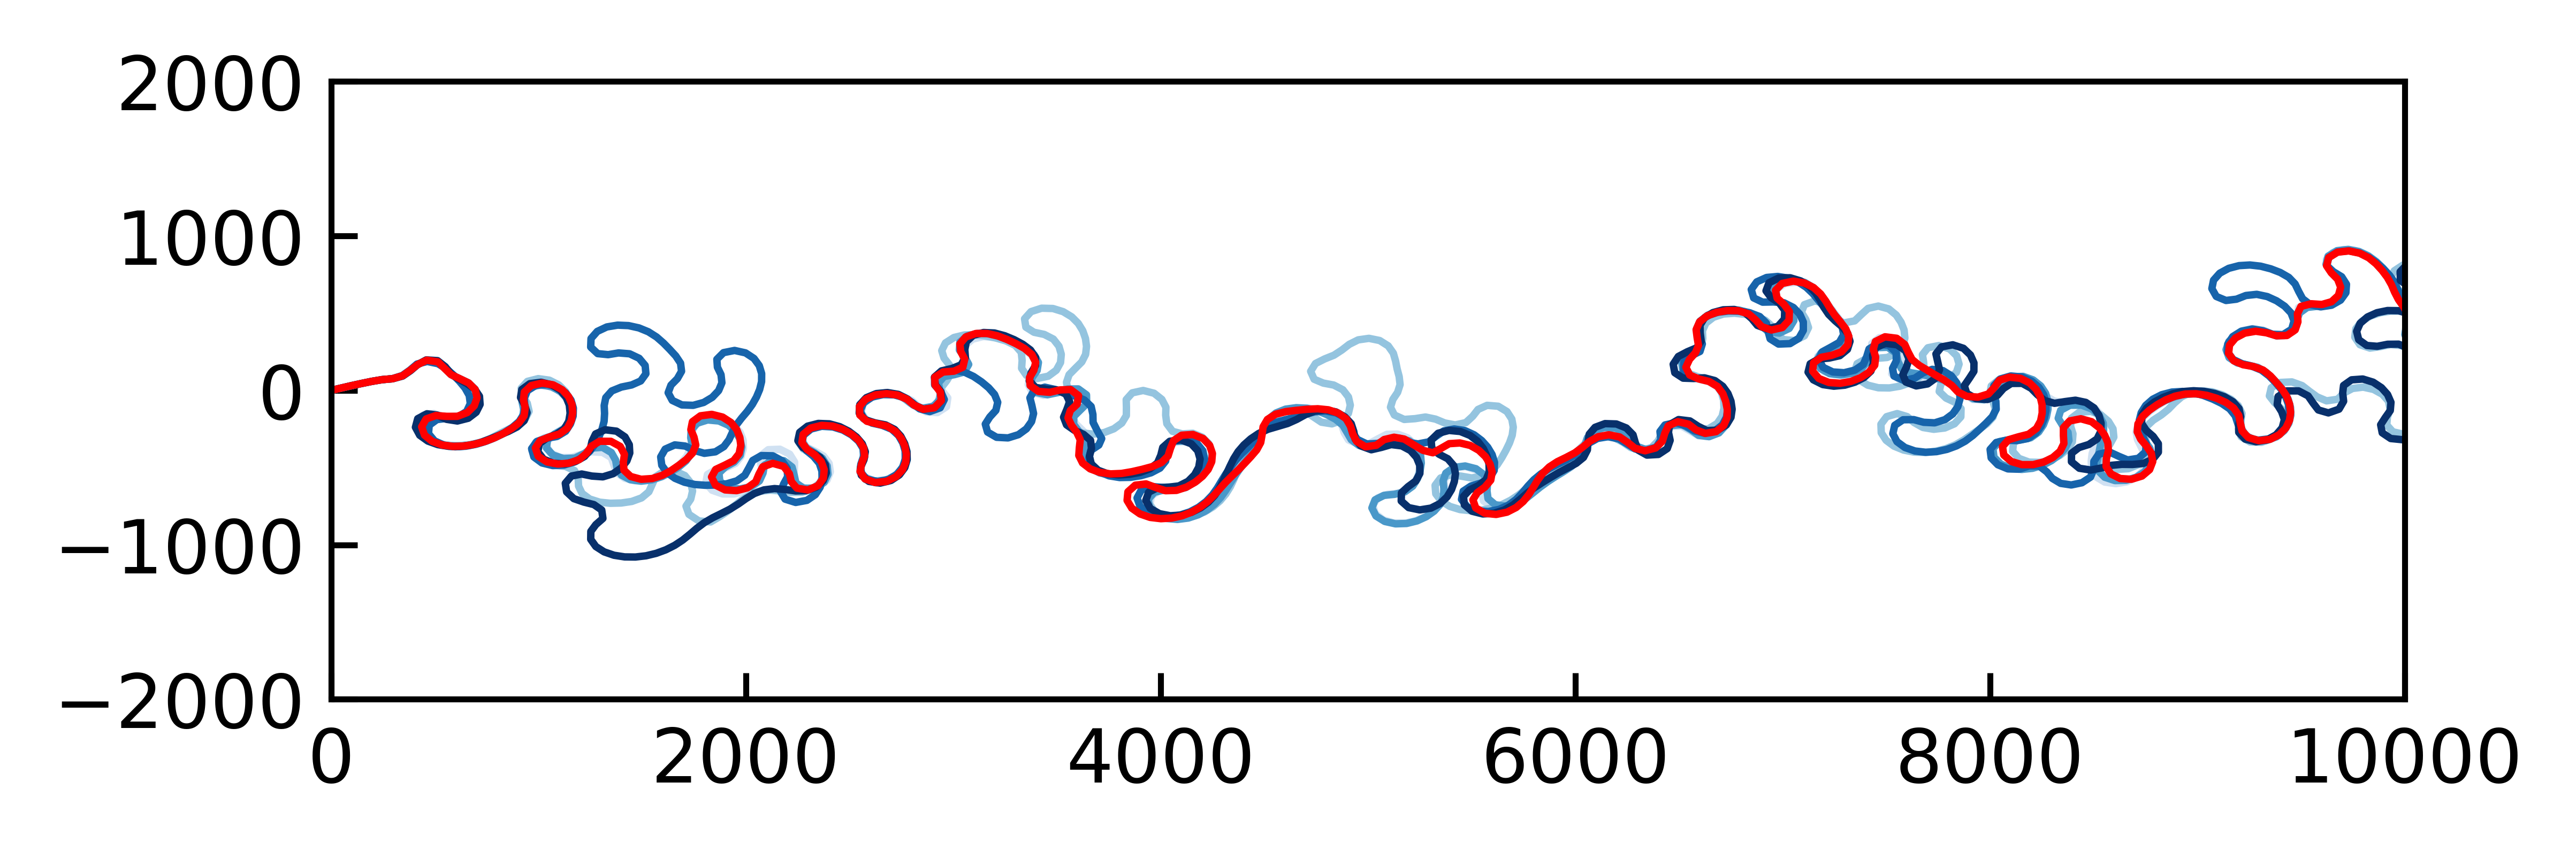

In [10]:
# Plot
plt.figure(figsize=(5,1.5))
cmap = get_cmap('Blues', len(perturbed_channels) + 1)

iterationtime = 400

# Perturbed runs
for i, chb in enumerate(perturbed_channels):
    plt.plot(chb.channels[iterationtime].x, chb.channels[iterationtime].y, lw=1,
                color=cmap(i + 1))

plt.plot(chb1.channels[iterationtime].x, chb1.channels[iterationtime].y, lw=1, color='red', label='Unperturbed')
plt.xlim([0,10000])
plt.ylim([-2000,2000])
plt.tick_params(axis='both', direction='in')
plt.show()

Figure 3

In [12]:
from scipy import interpolate
import numpy as np
import meanderpy as mp  # assuming you already have this

def run_meander_simulation(freq_multiplier=1, amplitude=1, multiplier=1,
                           perturb=False, perturb_value=1e-15, perturb_index=None):
    nit = 1501
    W = 50.0                 
    D = 1.0                  
    depths = D * np.ones((nit,))
    pad = 0
    deltas = 50.0
    Cfs = 0.003 * np.ones((nit,))
    crdist = 3 * W
    kl = 500.0 / (365 * 24 * 60 * 60.0) 
    kv = 1.0e-12
    dt = 0.1 * 0.5 * 365 * 24 * 60 * 60.0
    dens = 1000
    saved_ts = 1                
    Sl = 0.0
    t1, t2, t3 = 0, 0, 0
    aggr_factor = 2e-19

    # Generate initial geometry
    x_initial = np.linspace(0.1, 10000, 1500)
    y_initial = (amplitude * 100) * np.sin(freq_multiplier * np.pi * x_initial / 1000.0)
    z_initial = np.zeros_like(x_initial)

    # Apply perturbation
    if perturb:
        if perturb_index is None:
            perturb_index = len(y_initial) // 2  # default to midpoint
        y_initial[perturb_index] += perturb_value

    ch = mp.Channel(x_initial, y_initial, z_initial, W, depths[0])
    chb = mp.ChannelBelt([ch], [], [0.0], [])
    chb.migrate(nit, saved_ts, deltas, pad, crdist, depths, Cfs, kl, kv, dt, dens, t1, t2, t3, aggr_factor)
    return chb

# No perturbation
chb1 = run_meander_simulation(perturb=False)
chb2 = run_meander_simulation(perturb=True, perturb_value=1e-10, perturb_index=300)

100%|██████████| 1501/1501 [00:14<00:00, 106.76it/s]


/var/folders/pv/vxz_z6x905j13byjd_vxl_br0000gn/T/ipykernel_14381/1103567251.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Blues', len(chb1.channels))


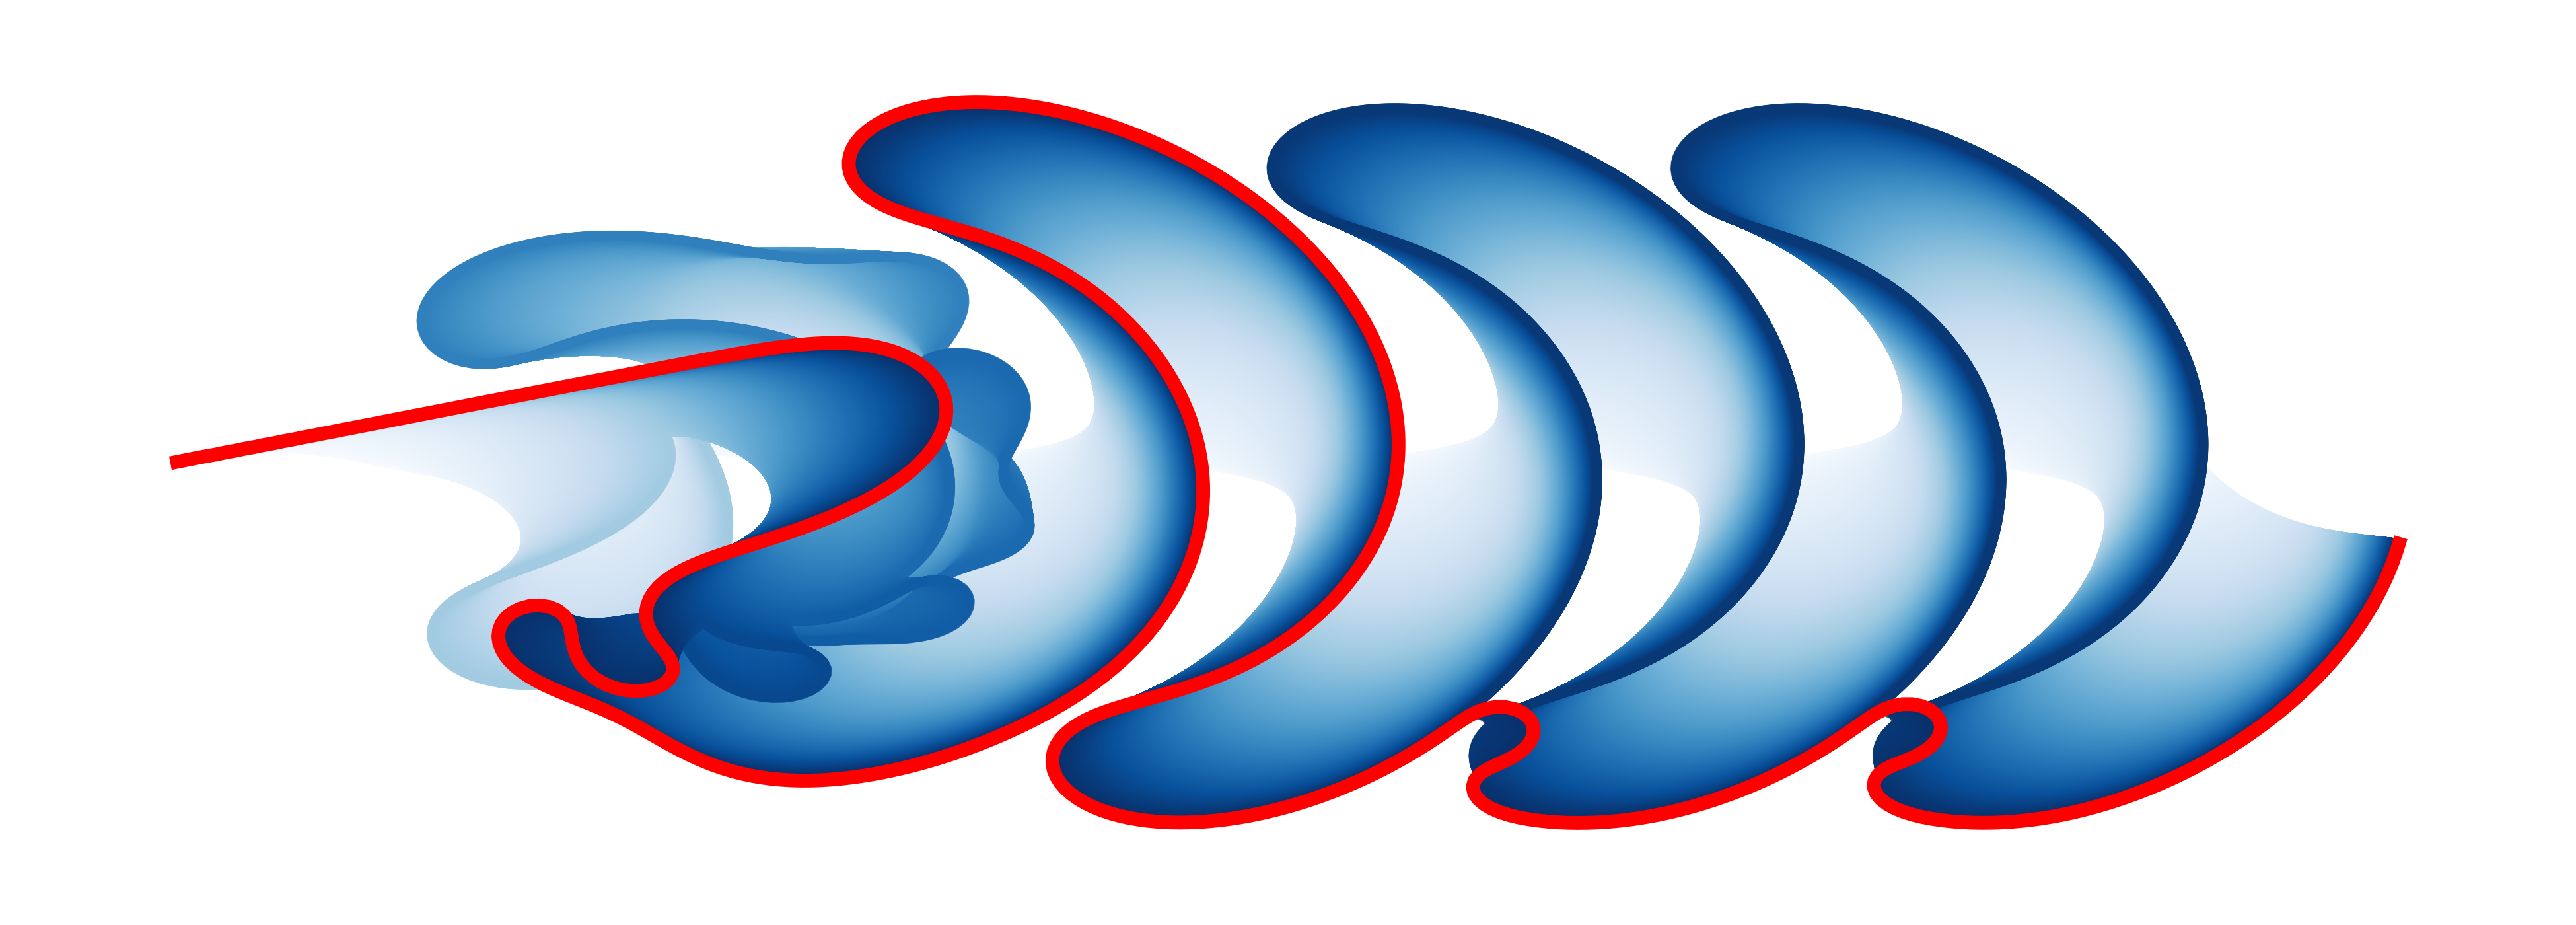

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# --- Sinuosity calculation function ---
def compute_sinuosity(channel):
    dx = np.diff(channel.x)
    dy = np.diff(channel.y)
    path_length = np.sum(np.sqrt(dx**2 + dy**2))
    straight_dist = np.sqrt((channel.x[-1] - channel.x[0])**2 + (channel.y[-1] - channel.y[0])**2)
    return path_length / straight_dist

# --- Compute sinuosity over time ---
sinuosity_chb1 = [compute_sinuosity(ch) for ch in chb1.channels]
sinuosity_chb2 = [compute_sinuosity(ch) for ch in chb2.channels]

# --- Plot: Unperturbed (blue) and Perturbed (red) channel evolutions ---
plt.figure(figsize=(4, 1.5))
cmap = get_cmap('Blues', len(chb1.channels))
for i, ch in enumerate(chb1.channels):
    plt.plot(ch.x, ch.y, lw=1, color=cmap(i), alpha=0.8)

# Plot the final channel from chb2 in red
plt.plot(chb2.channels[-1].x, chb2.channels[-1].y, color='red', lw=1.5, label='Perturbed channel')

plt.xlabel('X')
plt.ylabel('Y')
plt.axis("off")
plt.tight_layout()
plt.show()

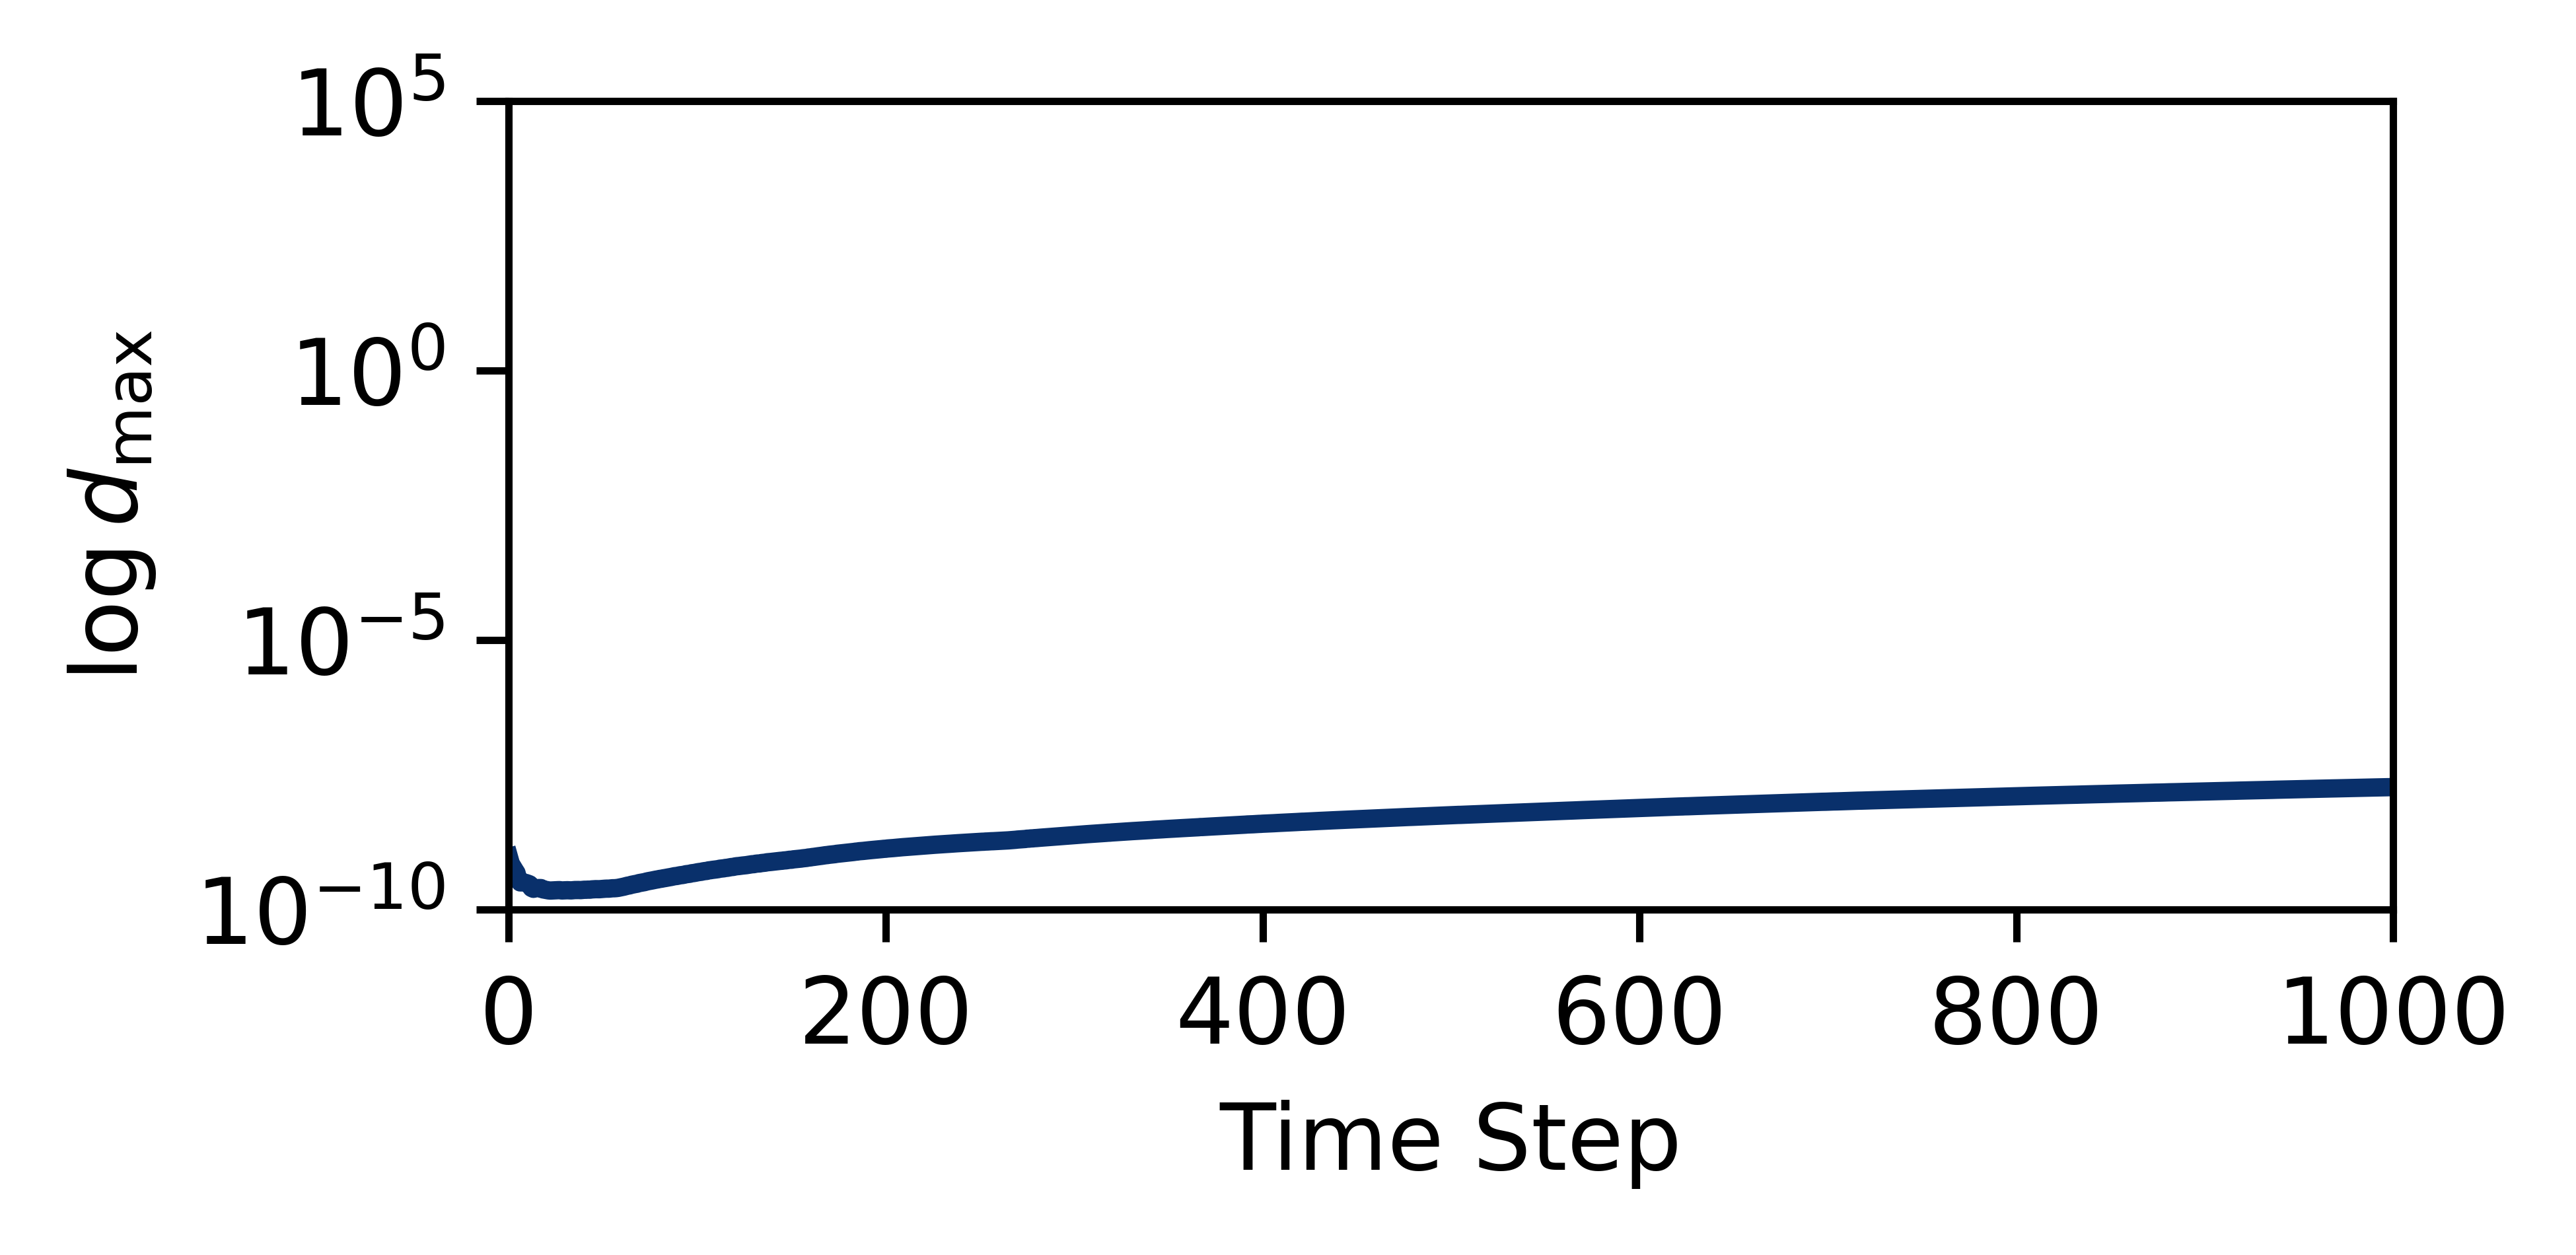

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Parameters
n_steps = min(len(chb1.channels), len(chb2.channels))
n_nodes_uniform = 1000  # number of resampled points per channel

# Store node-wise distances over time
all_dists = np.zeros((n_steps, n_nodes_uniform))

for t in range(n_steps):
    ch1 = chb1.channels[t]
    ch2 = chb2.channels[t]

    # Compute cumulative arclength
    s1 = np.hstack(([0], np.cumsum(np.sqrt(np.diff(ch1.x)**2 + np.diff(ch1.y)**2))))
    s2 = np.hstack(([0], np.cumsum(np.sqrt(np.diff(ch2.x)**2 + np.diff(ch2.y)**2))))

    s1 /= s1[-1]  # normalize to [0,1]
    s2 /= s2[-1]

    s_uniform = np.linspace(0, 1, n_nodes_uniform)

    # Interpolators for ch1
    f1_x = interp1d(s1, ch1.x, kind='linear', bounds_error=False, fill_value="extrapolate")
    f1_y = interp1d(s1, ch1.y, kind='linear', bounds_error=False, fill_value="extrapolate")

    # Interpolators for ch2
    f2_x = interp1d(s2, ch2.x, kind='linear', bounds_error=False, fill_value="extrapolate")
    f2_y = interp1d(s2, ch2.y, kind='linear', bounds_error=False, fill_value="extrapolate")

    # Evaluate on common arclength
    x1u, y1u = f1_x(s_uniform), f1_y(s_uniform)
    x2u, y2u = f2_x(s_uniform), f2_y(s_uniform)

    dist = np.sqrt((x1u - x2u)**2 + (y1u - y2u)**2)
    all_dists[t, :] = dist

max_dists = np.max(all_dists, axis=1)

window_size = 50  # Adjust this for more/less smoothing
kernel = np.ones(window_size) / window_size
smoothed_max_dists = np.convolve(max_dists, kernel, mode='same')

plt.figure(figsize=(4, 2))
plt.plot(max_dists, linewidth=2, linestyle='-',color='#09306b')
plt.yscale('log')
plt.xlabel("Time Step")
plt.ylabel("$\log d_{\max}$")
plt.xlim([0, 1000])
plt.ylim([1e-10, 1e5])
plt.xticks([0,200,400,600,800,1000])
plt.yticks([1e-10,1e-5,1e0,1e5])
plt.tight_layout()
plt.show()